Wczytano: val=(400, 30), train=(2400, 24), test=(600, 24)
Liczba profili na wykresie zbiorczym: 400


liczba
label       severity           
ok          nie_dotyczy     345
unknown     nie_dotyczy      10
zakoksowany srednie           7
            male              6
iglica      srednie           5
            male              5
lejacy      srednie           5
zakoksowany duze              4
pompa       male              4
lejacy      male              3
            duze              3
pompa       srednie           2
            duze              1

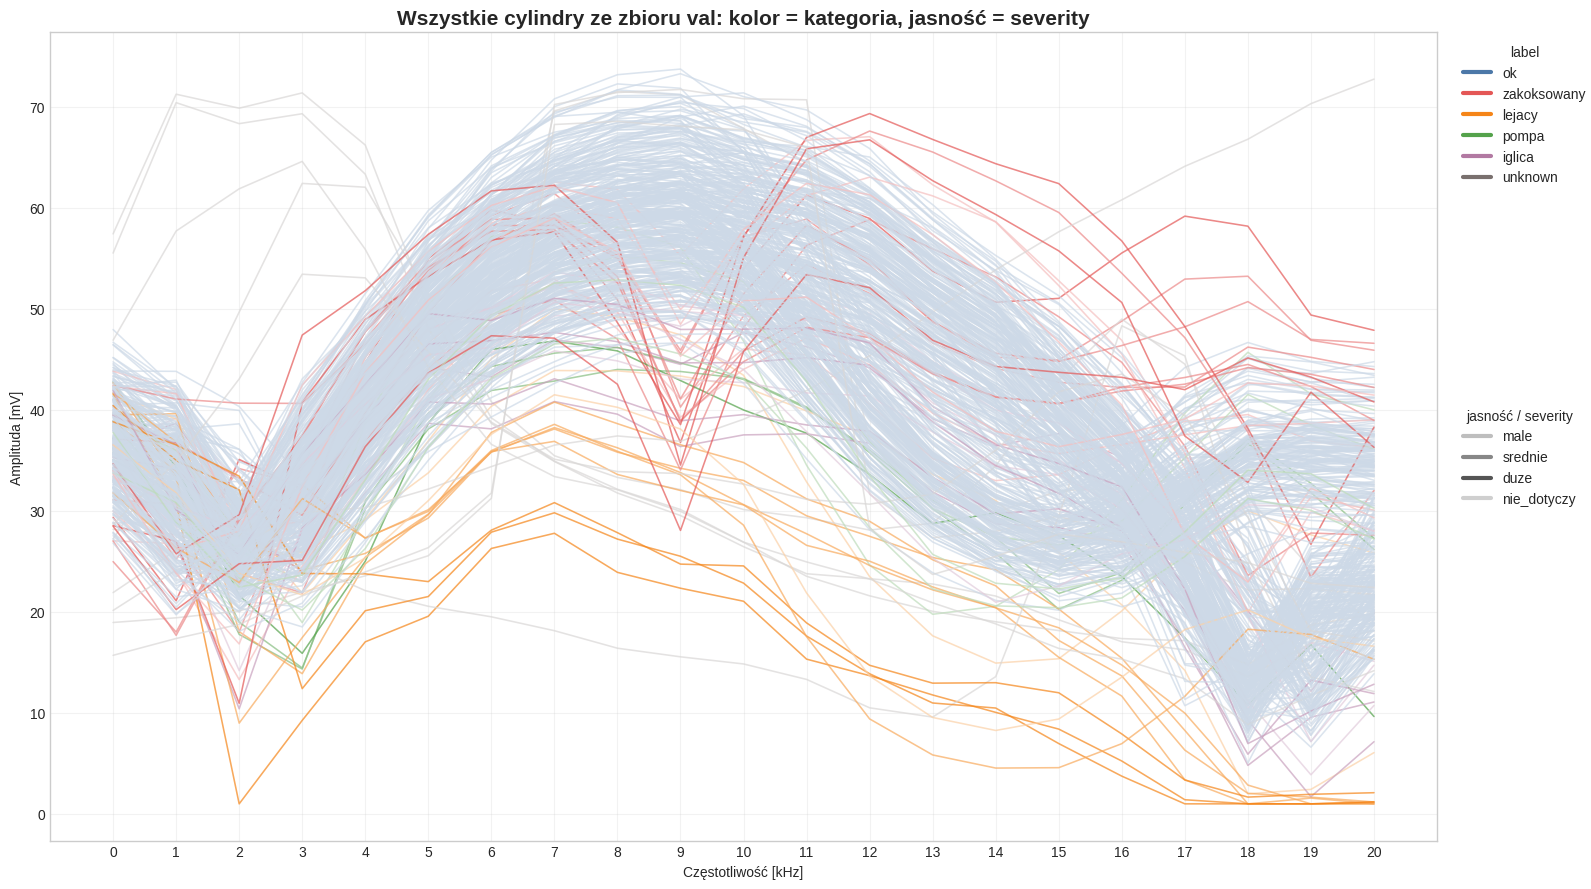

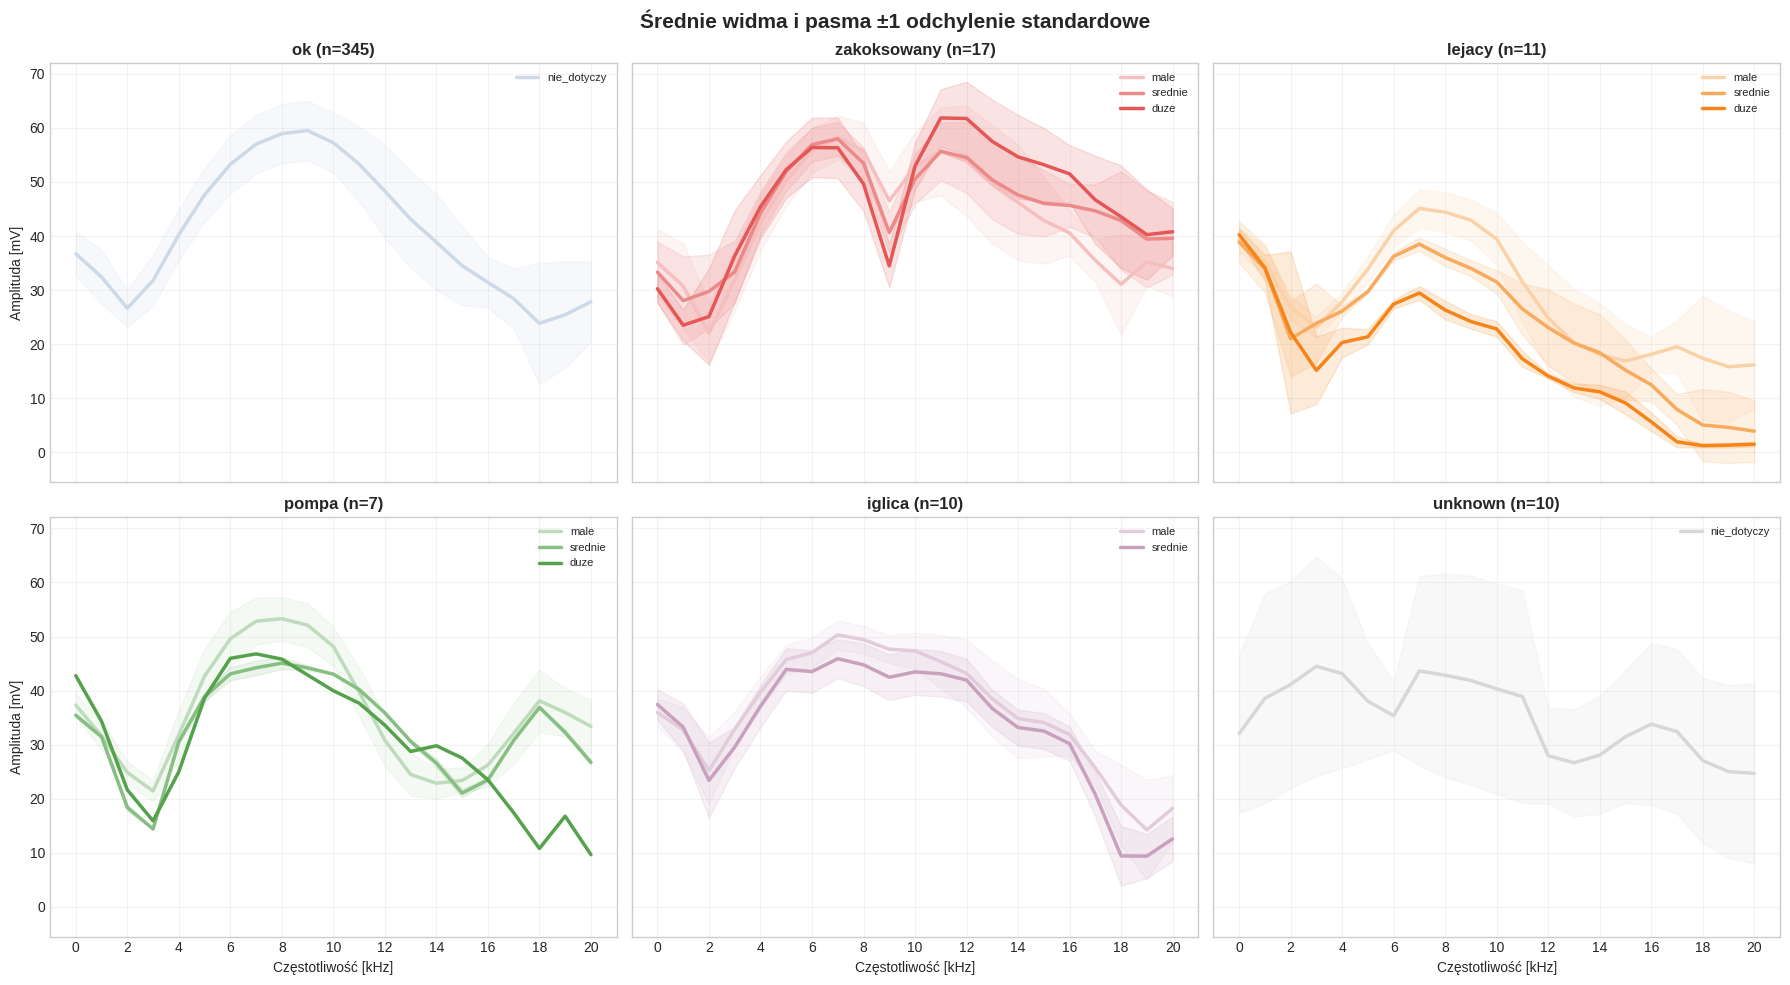

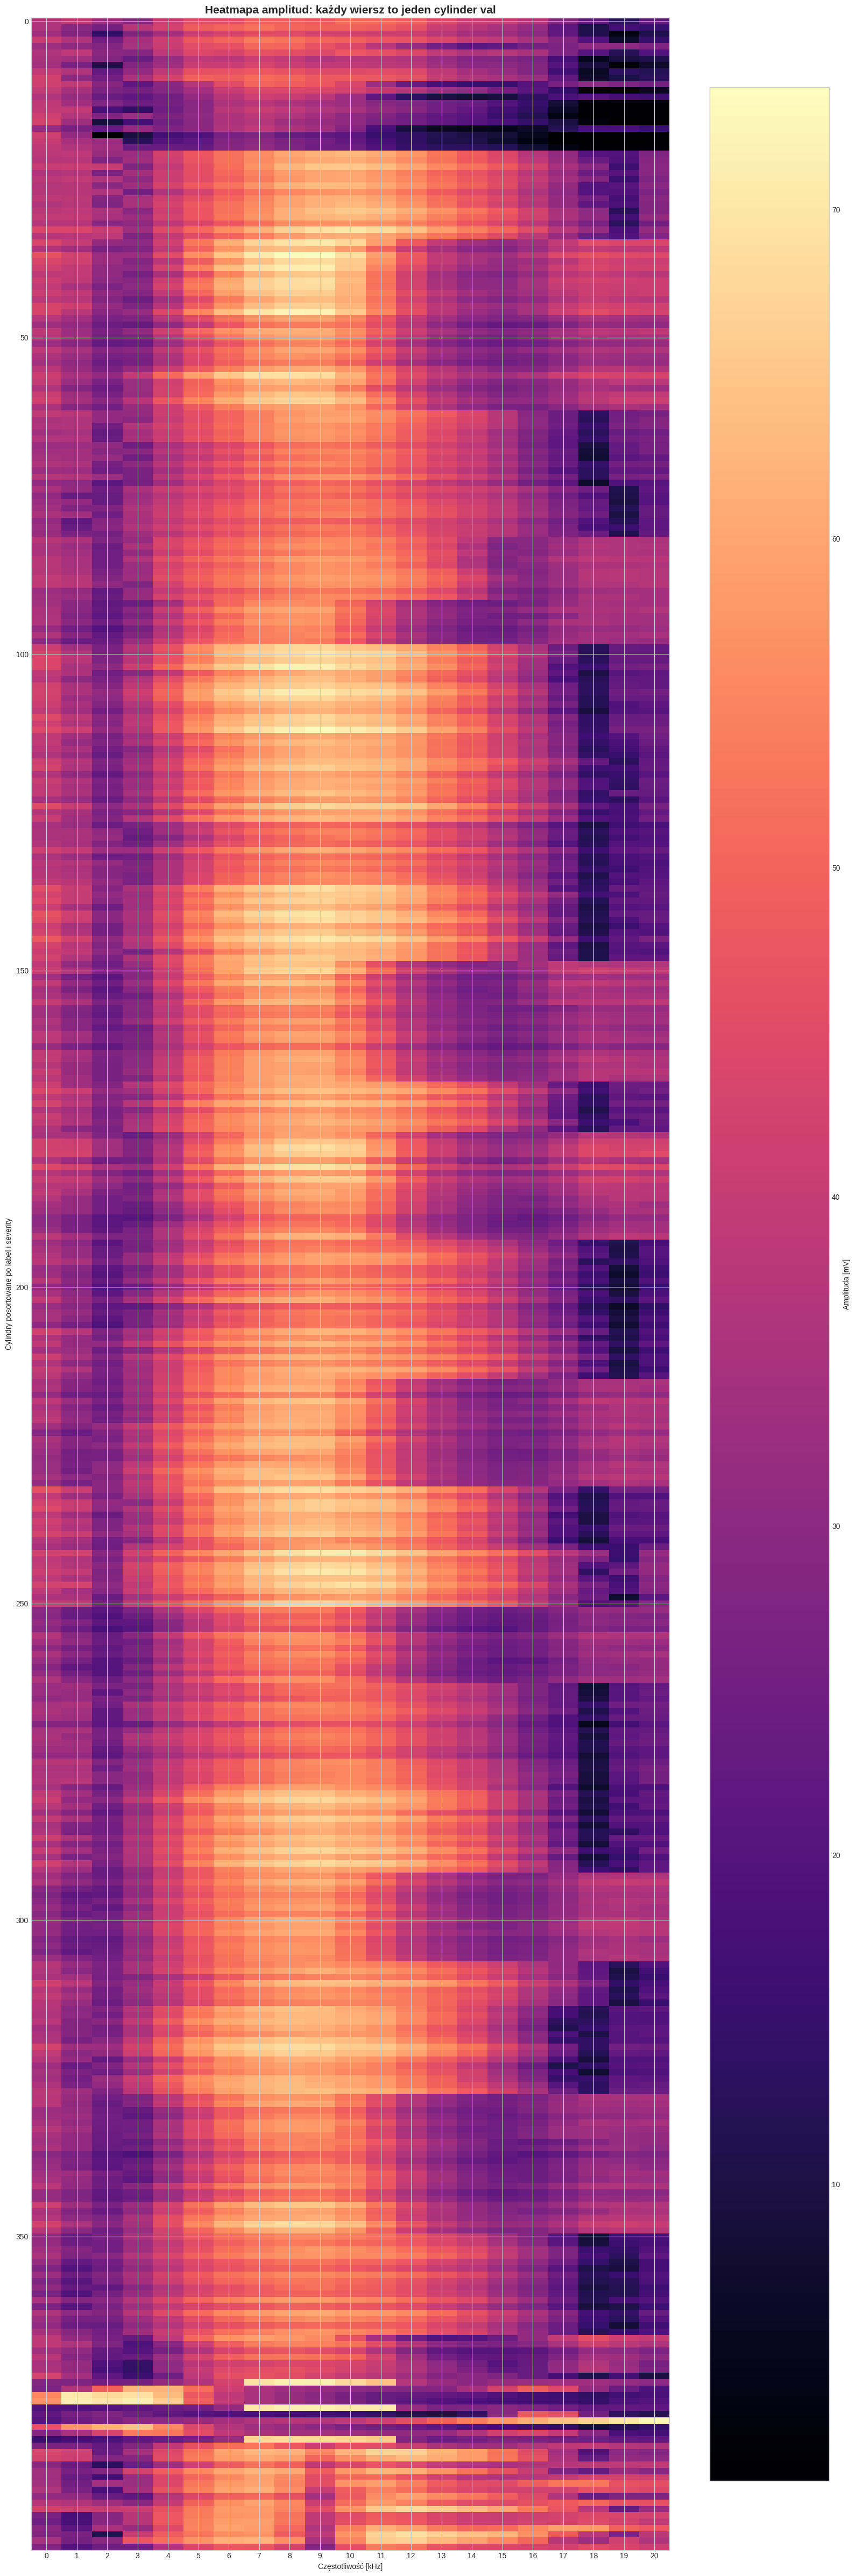

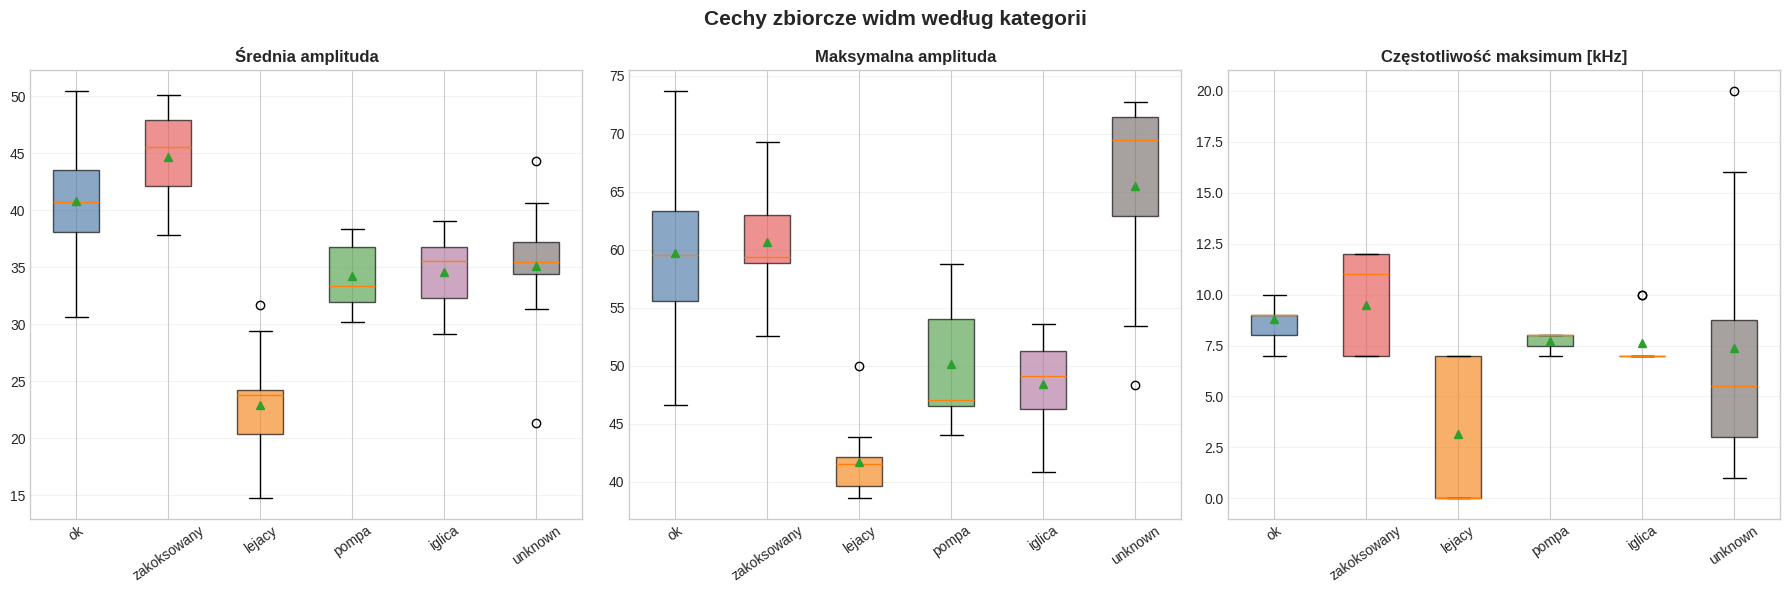

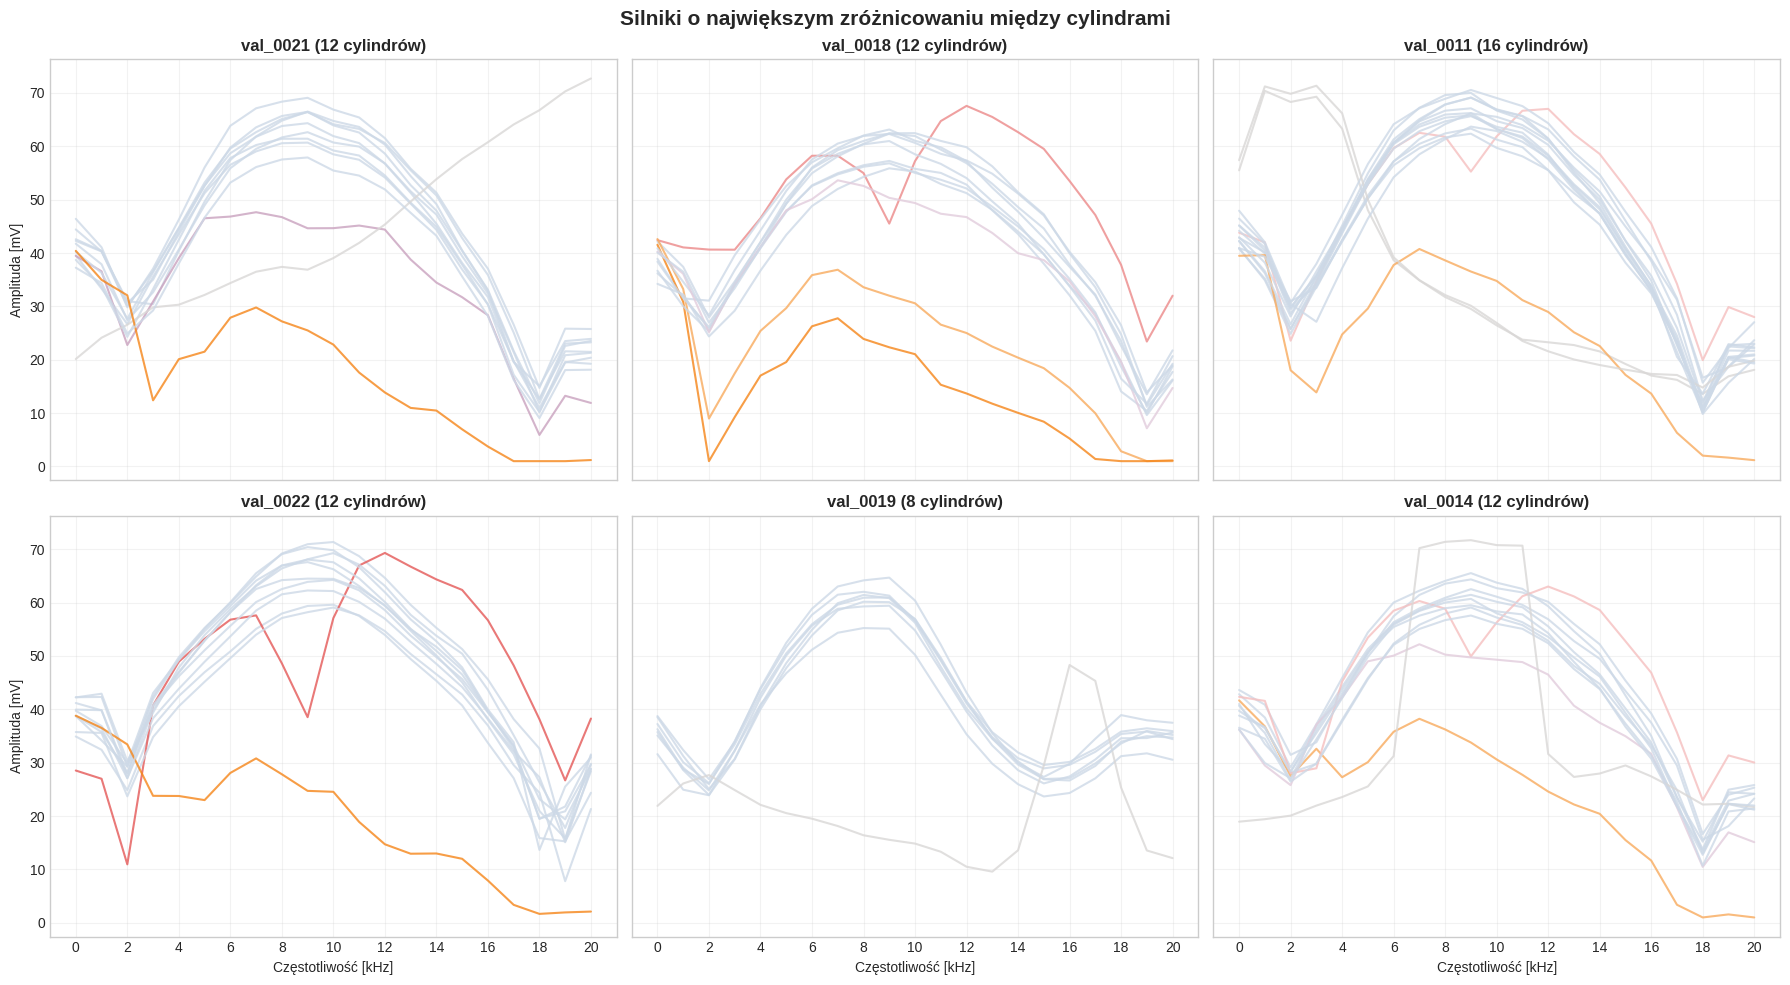

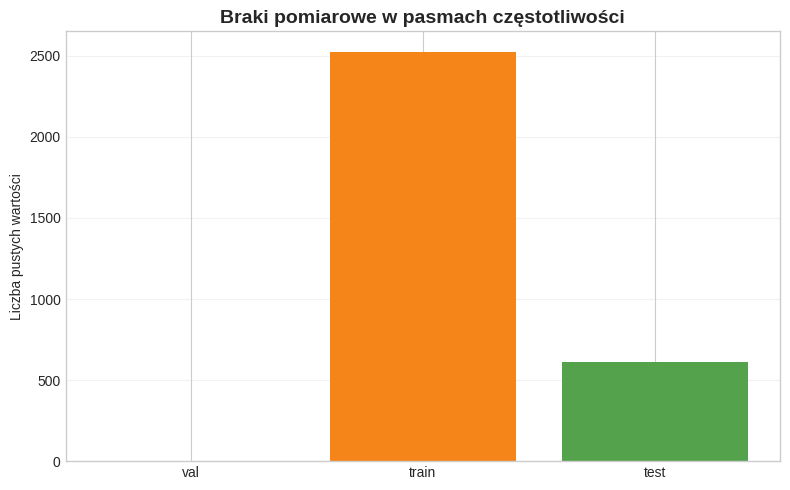

,zbior,wiersze,braki_przed_interpolacja
0,val,400,0
1,train,2400,2525
2,test,600,613


Wykresy zapisane w: /home/janek/Desktop/hackathon-engin/artifacts/visualizations


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
BASE_DIR = Path.cwd()
if not (BASE_DIR / "val.csv").exists():
    BASE_DIR = Path("/home/janek/Desktop/hackathon-engin")
OUT_DIR = BASE_DIR / "artifacts" / "visualizations"
OUT_DIR.mkdir(parents=True, exist_ok=True)

freq_cols = [f"mV_{i}" for i in range(21)]
frequency = np.arange(21)
frequency_label = "Częstotliwość [kHz]"
amplitude_label = "Amplituda [mV]"

val = pd.read_csv(BASE_DIR / "val.csv")
train = pd.read_csv(BASE_DIR / "train.csv")
test = pd.read_csv(BASE_DIR / "test.csv")

for frame in (val, train, test):
    frame[freq_cols] = frame[freq_cols].interpolate(axis=1, limit_direction="both")

label_colors = {
    "ok": "#4C78A8",
    "zakoksowany": "#E45756",
    "lejacy": "#F58518",
    "pompa": "#54A24B",
    "iglica": "#B279A2",
    "unknown": "#79706E",
}
severity_lightness = {"male": 0.62, "srednie": 0.30, "duze": 0.0, "nie_dotyczy": 0.72}
severity_order = ["male", "srednie", "duze", "nie_dotyczy"]

def severity_color(label, severity):
    base = np.array(to_rgb(label_colors.get(label, "#333333")))
    white_mix = severity_lightness.get(severity, 0.45)
    return tuple(base * (1 - white_mix) + white_mix)

val["profile_mean"] = val[freq_cols].mean(axis=1)
val["profile_max"] = val[freq_cols].max(axis=1)
val["peak_frequency"] = val[freq_cols].idxmax(axis=1).str.replace("mV_", "").astype(int)
val["severity_color"] = [severity_color(label, severity) for label, severity in zip(val["label"], val["severity"])]

print(f"Wczytano: val={val.shape}, train={train.shape}, test={test.shape}")
print(f"Liczba profili na wykresie zbiorczym: {len(val)}")
display(val[["label", "severity"]].value_counts().rename("liczba").to_frame())

fig, ax = plt.subplots(figsize=(16, 9))
for row in val.itertuples(index=False):
    ax.plot(
        frequency,
        [getattr(row, column) for column in freq_cols],
        color=row.severity_color,
        alpha=0.70,
        linewidth=1.15,
    )
ax.set_title("Wszystkie cylindry ze zbioru val: kolor = kategoria, jasność = severity", fontsize=15, weight="bold")
ax.set_xlabel(frequency_label)
ax.set_ylabel(amplitude_label)
ax.set_xticks(frequency)
ax.grid(alpha=0.25)
label_handles = [Line2D([0], [0], color=color, lw=3, label=label) for label, color in label_colors.items() if label in val["label"].unique()]
severity_handles = [Line2D([0], [0], color="#555555", lw=3, alpha=1 - severity_lightness[severity], label=severity) for severity in severity_order if severity in val["severity"].unique()]
legend_labels = ax.legend(handles=label_handles, title="label", loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.add_artist(legend_labels)
ax.legend(handles=severity_handles, title="jasność / severity", loc="upper left", bbox_to_anchor=(1.01, 0.55))
fig.tight_layout()
fig.savefig(OUT_DIR / "01_wszystkie_cylindry_val.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for ax, label in zip(axes.ravel(), label_colors):
    subset = val[val["label"] == label]
    for severity in severity_order:
        group = subset[subset["severity"] == severity]
        if group.empty:
            continue
        values = group[freq_cols].to_numpy()
        color = severity_color(label, severity)
        ax.plot(frequency, values.mean(axis=0), color=color, lw=2.5, label=severity)
        ax.fill_between(frequency, values.mean(axis=0) - values.std(axis=0), values.mean(axis=0) + values.std(axis=0), color=color, alpha=0.16)
    ax.set_title(f"{label} (n={len(subset)})", weight="bold")
    ax.set_xticks(frequency[::2])
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel(frequency_label)
for ax in axes[:, 0]:
    ax.set_ylabel(amplitude_label)
fig.suptitle("Średnie widma i pasma ±1 odchylenie standardowe", fontsize=15, weight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "02_srednie_widma_label_severity.png", dpi=180)
plt.show()

heatmap_data = val.sort_values(["label", "severity", "engine_id", "cylinder"], key=lambda column: column.map({value: index for index, value in enumerate(severity_order)}).fillna(-1) if column.name == "severity" else column)[freq_cols]
fig, ax = plt.subplots(figsize=(16, max(8, len(heatmap_data) * 0.12)))
im = ax.imshow(heatmap_data.to_numpy(), aspect="auto", cmap="magma", interpolation="nearest")
ax.set_title("Heatmapa amplitud: każdy wiersz to jeden cylinder val", fontsize=15, weight="bold")
ax.set_xlabel(frequency_label)
ax.set_ylabel("Cylindry posortowane po label i severity")
ax.set_xticks(np.arange(21))
fig.colorbar(im, ax=ax, label=amplitude_label)
fig.tight_layout()
fig.savefig(OUT_DIR / "03_heatmapa_cylindrow_val.png", dpi=180)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = [("profile_mean", "Średnia amplituda"), ("profile_max", "Maksymalna amplituda"), ("peak_frequency", "Częstotliwość maksimum [kHz]")]
for ax, (column, title) in zip(axes, metrics):
    groups = [val.loc[val["label"] == label, column].dropna().to_numpy() for label in label_colors if (val["label"] == label).any()]
    labels = [label for label in label_colors if (val["label"] == label).any()]
    box = ax.boxplot(groups, tick_labels=labels, patch_artist=True, showmeans=True)
    for patch, label in zip(box["boxes"], labels):
        patch.set_facecolor(label_colors[label])
        patch.set_alpha(0.65)
    ax.set_title(title, weight="bold")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("Cechy zbiorcze widm według kategorii", fontsize=15, weight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "04_cechy_widmowe_boxploty.png", dpi=180)
plt.show()

engine_spread = val.groupby("engine_id")[freq_cols].std().mean(axis=1).sort_values(ascending=False)
selected_engines = engine_spread.head(min(6, len(engine_spread))).index
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for ax, engine_id in zip(axes.ravel(), selected_engines):
    engine = val[val["engine_id"] == engine_id]
    for row in engine.itertuples(index=False):
        ax.plot(frequency, [getattr(row, column) for column in freq_cols], color=row.severity_color, lw=1.5, alpha=0.8)
    ax.set_title(f"{engine_id} ({len(engine)} cylindrów)", weight="bold")
    ax.set_xticks(frequency[::2])
    ax.grid(alpha=0.25)
for ax in axes[-1]:
    ax.set_xlabel(frequency_label)
for ax in axes[:, 0]:
    ax.set_ylabel(amplitude_label)
fig.suptitle("Silniki o największym zróżnicowaniu między cylindrami", fontsize=15, weight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "05_porownanie_cylindrow_w_silnikach.png", dpi=180)
plt.show()

missing = pd.DataFrame({
    "zbior": ["val", "train", "test"],
    "wiersze": [len(val), len(train), len(test)],
    "braki_przed_interpolacja": [pd.read_csv(BASE_DIR / name)[freq_cols].isna().sum().sum() for name in ["val.csv", "train.csv", "test.csv"]],
})
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(missing["zbior"], missing["braki_przed_interpolacja"], color=["#4C78A8", "#F58518", "#54A24B"])
ax.set_title("Braki pomiarowe w pasmach częstotliwości", fontsize=14, weight="bold")
ax.set_ylabel("Liczba pustych wartości")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "06_braki_danych.png", dpi=180)
plt.show()

display(missing)
print(f"Wykresy zapisane w: {OUT_DIR}")